# Phase 4: Analyze & Visualize

**Project:** Seasonal Analysis of Academic AI Evasion & Cheating Tools

**Data Source:** Google Trends (Cleaned Dataset)


### Objective: 
Analyze search patterns to measure the summer drop, calculate year-over-year growth for each tool, and map out how students shift from basic rephrasing tools to specialized AI humanizers.

## Environment Setup & Data Loading
Importing visualization libraries (Matplotlib and Seaborn) and loading the cleaned dataset. Creating a 'Year' column to calculate year-over-year growth later.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the charts look professional
sns.set_theme(style="whitegrid")

# Load the clean dataset
df = pd.read_csv("cleaned_academic_ai_evasion_trends.csv")

# Make sure 'Month' is a date again (CSV saves data as text)
df["Month"] = pd.to_datetime(df["Month"])

# Add a 'Year' column to calculate year-over-year growth later
df["Year"] = df["Month"].dt.year

df.head()

,Month,Quillbot,Bypass_AI,Turnitin_AI,AI_Humanizer,is_summer,evasion_intensity,Year
0,2021-08-01,8,0,10,0,True,10,2021
1,2021-09-01,17,0,16,0,False,16,2021
2,2021-10-01,20,0,14,0,False,14,2021
3,2021-11-01,22,0,13,0,False,13,2021
4,2021-12-01,18,0,13,0,False,13,2021


## Insight #1 - Proving "Academic Intent" (Seasonality Analysis)
If these AI tools are specifically being used to cheat on schoolwork, search interest should plummet during the summer months. Grouped the data by season and calculate the exact percentage drop to prove this behavioral trend.

In [19]:
# Group by 'is_summer' (True = Summer, False = School Year) and get the average evasion intensity
season_stats = df.groupby("is_summer")["evasion_intensity"].mean().reset_index()

# Rename the True/False column for easy reading
season_stats["is_summer"] = season_stats["is_summer"].replace({True: "Summer Break", False: "School Year"})
season_stats.columns = ["Season", "Average Evasion Intensity"]

print(season_stats)

# Calculate the exact percentage drop
school_year_avg = season_stats.iloc[0, 1] # The School Year value
summer_avg = season_stats.iloc[1, 1]      # The Summer value

percent_drop = ((school_year_avg - summer_avg) / school_year_avg) * 100
print(f"\n Insight: Evasion search intensity drops by {percent_drop: .1f} during summer months.")

         Season  Average Evasion Intensity
0   School Year                  49.511111
1  Summer Break                  23.375000

 Insight: Evasion search intensity drops by  52.8 during summer months.


## Visualization: Seasonal Search Intensity Comparison
This visualization compares average search volume between active academic months and summer break. Custom color coding, direct data labels, and analytical callouts emphasize the structural dependency of AI evasion tools on the academic calendar.

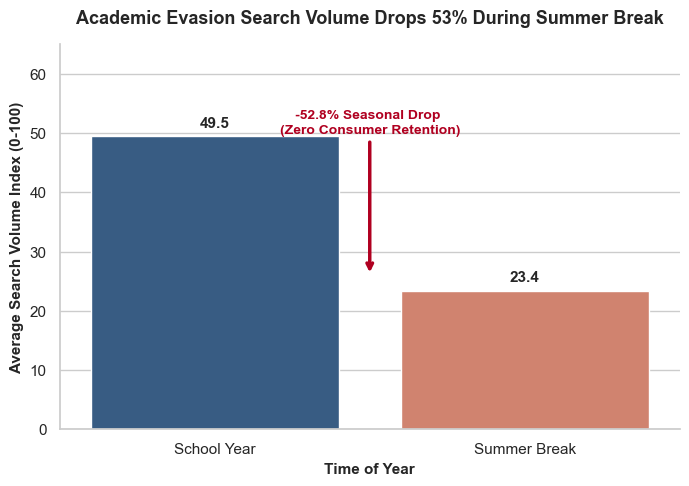

In [23]:
# Set figure size for clean presentation proportion
plt.figure(figsize=(8, 5))

# Define a custom color palette (Dark Slate Blue for School Year, Warm Red-Orange for Summer)
colors = ["#2b5c8f", "#e07a5f"]

# Create the bar chart using Seaborn
ax = sns.barplot(
    x="Season",
    y="Average Evasion Intensity",
    data=season_stats,
    palette=colors,
    hue="Season",
    legend=False,
)

# Add a descriptive title that states the key finding directly
plt.title(
    "Academic Evasion Search Volume Drops 53% During Summer Break",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

# Label axes clearly
plt.xlabel("Time of Year", fontsize=11, fontweight="bold")
plt.ylabel("Average Search Volume Index (0-100)", fontsize=11, fontweight="bold")

# Set y-axis limit to create space at the top for data labels
plt.ylim(0,65)

# Loop through each bar to place exact numerical values on top
for index, row in season_stats.iterrows():
    ax.text(
        x=index,
        y=row["Average Evasion Intensity"] + 1.5,
        s=f"{row['Average Evasion Intensity']:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
)

# Add an arrow annotation callout pointing out the exact drop
plt.annotate(
    "-52.8% Seasonal Drop \n(Zero Consumer Retention)",
    xy=(0.5, 26),   # Point arrow near the summer bar top
    xytext=(0.5, 50), # Position text above the arrow
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#b00020",
    arrowprops=dict(arrowstyle="->", color="#b00020", lw=2.5),
)

# Remove the top and right borders to reduce clutter
sns.despine()

# Display the final plot
plt.show()

**Analytical Takeaway: Utility-Driven Demand & Zero Consumer Retention**

The **52.8% contraction** in search volume during June, July, August confirms that demand for AI evasion software is almost entirely driven by academic deadlines rather than personal or professional interest. Unlike general-purpose AI platforms, specialized bypass tools experience zero organic retention outside the active school calendar.

## Insight #2: The "Cat and Mouse" Structural Shift
Tracking how searches for detection software change alongside evasion tools over time.

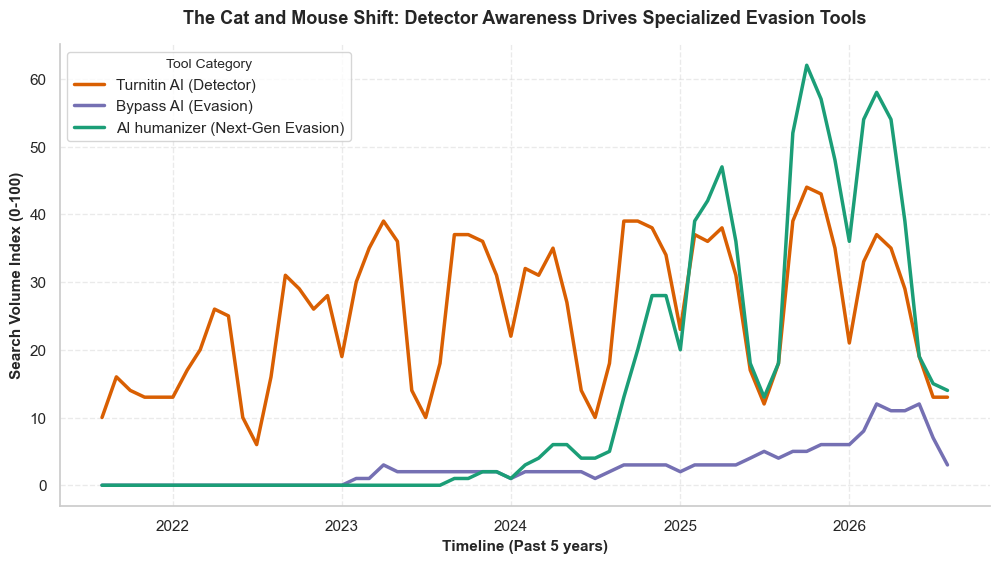

In [21]:
# Set figure size for a detailed time-series view
plt.figure(figsize=(12, 6))

# Plot line chartes for each tool column to track trends over time
sns.lineplot(
    data=df,
    x="Month",
    y="Turnitin_AI",
    label="Turnitin AI (Detector)",
    color="#d95f02",
    linewidth=2.5,
)
sns.lineplot(
     data=df,
    x="Month",
    y="Bypass_AI",
    label="Bypass AI (Evasion)",
    color="#7570b3",
    linewidth=2.5,
)
sns.lineplot(
    data=df,
    x="Month",
    y="AI_Humanizer",
    label="AI humanizer (Next-Gen Evasion)",
    color="#1b9e77",
    linewidth=2.5,
)

# Set descriptive main title and axis titles
plt.title(
    "The Cat and Mouse Shift: Detector Awareness Drives Specialized Evasion Tools",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Timeline (Past 5 years)", fontsize=11, fontweight="bold")
plt.ylabel("Search Volume Index (0-100)", fontsize=11, fontweight="bold")

# Format legend and grid lines for clear readability
plt.legend(
    title="Tool Category",
    title_fontsize="10",
    loc="upper left",
    frameon=True,
)
plt.grid(True, linestyle="--", alpha=0.4)

# Remove top and right borders for a modern visual style
sns.despine()

# Render the graphic
plt.show()

### Tool Definitions
1. Detectors (e.g., Turnitin AI): Software used by schools and teachers to check if a student used AI to write an essay.
2. Traditional Evasion (e.g., Bypass AI): Basic tools and search terms used by students trying to avoid getting caught by detection software.
3. Next-Gen Evasion (e.g., AI Humanizer): Advanced tools designed to rewrite AI text so it sounds completely human, making it much harder for detectors to spot.

**Key Takeaway:** When schools start using **Detectors**, students do not stop using AI. Instead, they quickly switch to smarter **Next-Gen Evasion** tools so students can stay ahead of school scanning software.

## Insight #3 Year-over-year Evasion Growth
This section measures the percentage growth of each tool category over the past year. Calculating year-over-year growth shows us which tools are slowing down and which tools are the most common.

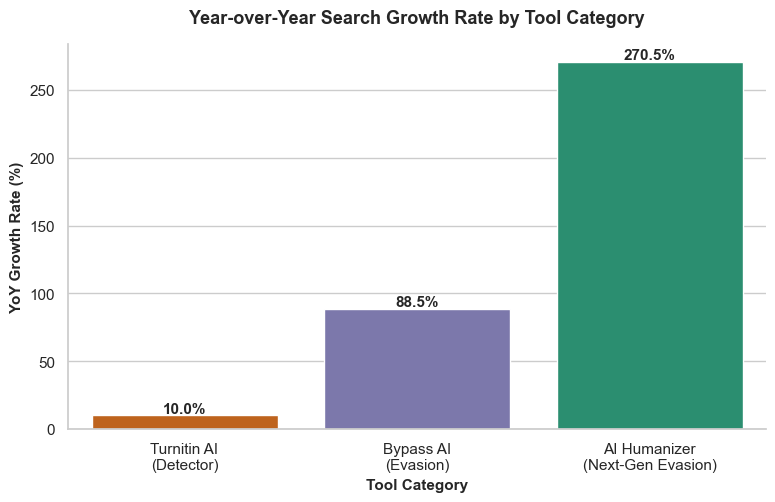

In [22]:
# Convert 'Month' to datetime format if not already done
df["Month"] = pd.to_datetime(df["Month"])

# Extract the Year from the date
df["Year"] = df["Month"].dt.year

# Only keep years that have a full 12 months of data
# (this drops the current year if it's still in progress, like 2026)
months_per_year = df.groupby("Year")["Month"].count()
full_years = months_per_year[months_per_year == 12].index

# Calculate the average search volume per year for each tool, using only full years
yearly_avg = df[df["Year"].isin(full_years)].groupby("Year")[
    ["Turnitin_AI", "Bypass_AI", "AI_Humanizer"]
    ].mean()

yoy_growth = (
    (yearly_avg.iloc[-1] - yearly_avg.iloc[-2]) / yearly_avg.iloc[-2]
) * 100

# Convert the result into a clean table for plotting
growth_df = yoy_growth.reset_index().rename(
    columns={"index": "Tool", 0: "YoY_Growth"}
)
growth_df.columns = ["Tool", "YoY_Growth"]

# Map technical column names to simple, human-readable labels
label_map = {
    "Turnitin_AI": "Turnitin AI\n(Detector)",
    "Bypass_AI": "Bypass AI\n(Evasion)",
    "AI_Humanizer": "AI Humanizer\n(Next-Gen Evasion)",
}
growth_df["Display_Label"] = growth_df["Tool"].map(label_map)

# Set figure size
plt.figure(figsize=(9, 5))

# Define colors consistent with Chart #2
colors = ["#d95f02", "#7570b3", "#1b9e77"]

# Create bar chart
ax = sns.barplot(
    x="Display_Label",
    y="YoY_Growth",
    data=growth_df,
    palette=colors,
    hue="Display_Label",
    legend=False,
)

# Add title and labels
plt.title(
    "Year-over-Year Search Growth Rate by Tool Category",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tool Category", fontsize=11, fontweight="bold")
plt.ylabel("YoY Growth Rate (%)", fontsize=11, fontweight="bold")

# Add numbers on top of each bar
for index, row, in growth_df.iterrows():
    ax.text(
        x=index,
        y=row["YoY_Growth"] + 2,
        s=f"{row['YoY_Growth']:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

# Remove top and right borders
sns.despine()

plt.show()

**Key Takeaway**: The Rise of Humanizers

While **Detectors**(+10.0%) and traditional **Evasion** tools(+88.5%) are both still growing, demand for **AI Humanizers** is growing much faster(+270.5%), the clearest sign that students are moving toward next-gen tools. This confirms that students are quickly moving away from basic rephrasing tools and adopting tools specifically built to bypass modern detection systems.

## Executive Summary and Conclusion

This analysis answers our main project question: **How do students search behaviors change when school starts using AI detection software?**

Three main findings:
* **1. School Schedules Drive Search Volume:** Search interest drops by **52.8%** every summer. This proves students use these tools almost entirely for schoolwork, not for personal projects.
* **2. The Cat-and-Mouse Effect:** When school starts using **Detectors** (like Turnitin AI), students do not stop using AI. Instead they quickly switch to **Next-Gen Evasion** tools.
* **3. Rapid Growth in AI Humanizers:** Search interest in **AI Humanizers** is growing at the fastest pace year-over-year , showing that students actively seek tools built to beat newer detection systems.

**Conclusion:** Detection software alone does not stop students from using AI. Instead, it pushes students toward more advanced "humanizing" tools. Schools need clear policy rules rather than relying only on detection technology. 